In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [7]:
df = pd.read_csv('./safe.csv', encoding='cp949')
df.head()

,시설종류,대상시설명,소재지도로명주소,소재지지번주소,위도,경도,관리기관명,관할경찰서명,CCTV설치여부,CCTV설치대수,보호구역도로폭,데이터기준일자,제공기관코드,제공기관명
0,유치원,이지유치원,경기도 화성시 만세구 향남읍 행정동로 42,경기도 화성시 만세구 향남읍 행정리 484번지,37.127816,126.927260,경기도 화성시 만세구 경제교통과,화성서부경찰서,N,NaN,NaN,2026-02-01,5530000,경기도 화성시
1,초등학교,이솔초등학교,경기도 화성시 동탄구 동탄순환대로8길 26,경기도 화성시 동탄구 장지동 967번지,37.163299,127.109723,경기도 화성시 동탄구 경제교통과,화성동탄경찰서,N,NaN,NaN,2026-02-01,5530000,경기도 화성시
2,유치원,이룸유치원,경기도 화성시 만세구 향남읍 상신초교길 37,경기도 화성시 만세구 향남읍 상신리 846번지,37.094963,126.902586,경기도 화성시 만세구 경제교통과,화성서부경찰서,N,NaN,NaN,2026-02-01,5530000,경기도 화성시
3,어린이집,으뜸어린이집,경기도 화성시 병점구 용주로12번길 18,경기도 화성시 병점구 송산동 100-100번지,37.206779,127.016299,경기도 화성시 병점구 안전건설과,화성동탄경찰서,N,NaN,NaN,2026-02-01,5530000,경기도 화성시
4,초등학교,율목초등학교,경기도 화성시 병점구 영통로50번길 19,경기도 화성시 병점구 반월동 879번지,37.237055,127.064359,경기도 화성시 병점구 안전건설과,화성동탄경찰서,N,NaN,NaN,2026-02-01,5530000,경기도 화성시


In [11]:
data1 = df[['시설종류', '대상시설명', '소재지도로명주소', '위도', '경도',
            'CCTV설치여부', 'CCTV설치대수', '제공기관명']]
data1 = data1.fillna(0)
data1.head()

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
0,유치원,이지유치원,경기도 화성시 만세구 향남읍 행정동로 42,37.127816,126.927260,N,0.0,경기도 화성시
1,초등학교,이솔초등학교,경기도 화성시 동탄구 동탄순환대로8길 26,37.163299,127.109723,N,0.0,경기도 화성시
2,유치원,이룸유치원,경기도 화성시 만세구 향남읍 상신초교길 37,37.094963,126.902586,N,0.0,경기도 화성시
3,어린이집,으뜸어린이집,경기도 화성시 병점구 용주로12번길 18,37.206779,127.016299,N,0.0,경기도 화성시
4,초등학교,율목초등학교,경기도 화성시 병점구 영통로50번길 19,37.237055,127.064359,N,0.0,경기도 화성시


In [9]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14635 entries, 0 to 14634
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   시설종류      14635 non-null  str    
 1   대상시설명     14635 non-null  str    
 2   소재지도로명주소  14635 non-null  object 
 3   위도        14635 non-null  float64
 4   경도        14635 non-null  float64
 5   관리기관명     14635 non-null  str    
 6   CCTV설치여부  14635 non-null  str    
 7   CCTV설치대수  14635 non-null  float64
dtypes: float64(3), object(1), str(4)
memory usage: 914.8+ KB


In [19]:
num0 = data1['제공기관명'].str.contains('서울').sum()
num1 = data1['제공기관명'].str.contains('대전').sum()
num2 = data1['제공기관명'].str.contains('대구').sum()
num3 = data1['제공기관명'].str.contains('부산').sum()
num4 = data1['제공기관명'].str.contains('광주').sum()
num5 = data1['제공기관명'].str.contains('경기').sum()
num6 = data1['제공기관명'].str.contains('강원').sum()
num7 = data1['제공기관명'].str.contains('경상').sum()
num8 = data1['제공기관명'].str.contains('전라').sum()
num9 = data1['제공기관명'].str.contains('충청').sum()
num10 = data1['제공기관명'].str.contains('제주').sum()
print(num0, num1, num2, num3, num4, num5, num6, num7, num8, num9, num10)

1617 657 718 809 477 2936 609 2549 810 1460 338


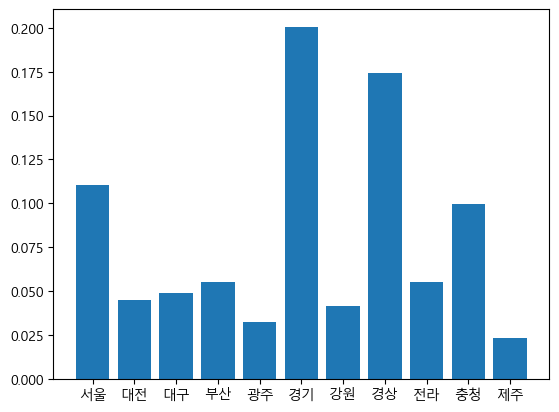

In [31]:
region = ['서울', '대전', '대구', '부산', '광주', '경기', '강원', '경상', '전라', '충청', '제주']
num = []

for i in region:
    data = data1['제공기관명'].str.contains(i).mean()
    num.append(data)

n_data = len(region)
index = np.arange(n_data)
plt.bar(index, num, tick_label=region)
plt.show()

# 서울

In [20]:
sl = data1[data1['제공기관명'].str.contains('서울')]
sl

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
1446,대안학교,한밀기독학교,서울특별시 강서구 수명로21길 88(발산1동),37.550862,126.827701,N,0.0,서울특별시 강서구
1447,대안학교,서울빛들발도르프학교,서울특별시 강서구 수명로21길 96(발산1동),37.551294,126.827838,N,0.0,서울특별시 강서구
1448,학원,스터디플랜독서실,서울특별시 강서구 곰달래로49길 80(화곡동),37.534937,126.856235,N,0.0,서울특별시 강서구
1449,초등학교,개화초등학교,서울특별시 강서구 양천로 11 (방화동),37.573944,126.804646,Y,2.0,서울특별시 강서구
1450,초등학교,가양초등학교,서울특별시 강서구 허준로 186 (가양동),37.562217,126.858522,Y,1.0,서울특별시 강서구
...,...,...,...,...,...,...,...,...
14085,초등학교,신자초등학교,서울특별시 광진구 뚝섬로46길 64,37.530245,127.075588,Y,7.0,서울특별시 광진구
14086,초등학교,동자초등학교,서울특별시 광진구 뚝섬로 561,37.535058,127.072179,Y,3.0,서울특별시 광진구
14087,초등학교,동의초등학교,서울특별시 광진구 영화사로 111,37.553422,127.099047,Y,7.0,서울특별시 광진구
14088,초등학교,구의초등학교,서울특별시 광진구 광나루로30길 49,37.543007,127.080312,Y,7.0,서울특별시 광진구


# 대전

In [17]:
dj = data1[data1['제공기관명'].str.contains('대전')]
dj

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
1786,초등학교,자운초등학교,대전광역시 유성구 자운로 97번길 380(신봉동),36.412521,127.337435,Y,0.0,대전광역시 유성구
1787,초등학교,송강초등학교(병설),대전광역시 유성구 송강로42번길6(송강동),36.434153,127.383847,Y,0.0,대전광역시 유성구
1788,초등학교,상지초등학교(병설),대전광역시 유성구 노은동로165(지족동),36.375391,127.322172,Y,0.0,대전광역시 유성구
1789,초등학교,봉암초등학교(병설),대전광역시 유성구 궁동로 21(궁동),36.364087,127.347722,Y,0.0,대전광역시 유성구
1790,초등학교,덕송초등학교(병설),대전광역시 유성구 현충원로265(덕명동),36.361384,127.302523,Y,0.0,대전광역시 유성구
...,...,...,...,...,...,...,...,...
14559,유치원,신계초교병설,대전광역시 서구 복수동로 26,36.301929,127.378058,Y,2.0,대전광역시 서구
14560,유치원,도마초교병설,대전광역시 서구 배재로172번길 23,36.323823,127.371234,Y,1.0,대전광역시 서구
14561,유치원,샘머리초교병설,대전광역시 서구 유등로 879,36.363398,127.393255,Y,1.0,대전광역시 서구
14562,유치원,가장초교병설,대전광역시 서구 가장로 150,36.330638,127.387869,Y,3.0,대전광역시 서구


# 대구

In [18]:
dg = data1[data1['제공기관명'].str.contains('대구')]
dg

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
960,초등학교,송현초등학교,대구광역시 달서구 송현로 128,35.828687,128.544830,Y,13.0,대구광역시 달서구
961,초등학교,감천초등학교,대구광역시 달서구 구마로12길 60,35.835267,128.533098,Y,6.0,대구광역시 달서구
962,초등학교,감삼초등학교,대구광역시 달서구 당산로 123,35.849180,128.545146,Y,6.0,대구광역시 달서구
963,초등학교,대곡초등학교,대구광역시 달서구 도원남로 60,35.803299,128.535749,Y,4.0,대구광역시 달서구
964,초등학교,대남초등학교,대구광역시 달서구 월배로68길 91,35.824186,128.551750,Y,11.0,대구광역시 달서구
...,...,...,...,...,...,...,...,...
12694,어린이집,참좋은 어린이집,대구광역시 남구 중앙대로 126,35.844351,128.591000,Y,1.0,대구광역시 남구
12695,유치원,아이린유치원,대구광역시 남구 효동길 14-4,35.839628,128.599626,Y,8.0,대구광역시 남구
12696,어린이집,더플로우 어린이집,대구광역시 남구 대봉로30길40,35.852149,128.605307,Y,1.0,대구광역시 남구
12697,유치원,드림유치원,대구광역시 남구 대봉로30길36-8,35.851708,128.605127,Y,1.0,대구광역시 남구


# 부산

In [21]:
bs = data1[data1['제공기관명'].str.contains('부산')]
bs

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
1301,유치원,가동유치원,부산광역시 기장군 정관읍 정관5로 100,35.326899,129.178585,Y,3.0,부산광역시 기장군
1302,유치원,행복엔젤유치원,부산광역시 기장군 기장읍 차성서로 44,35.237146,129.210349,Y,15.0,부산광역시 기장군
1303,유치원,내리초등학교 병설유치원,부산광역시 기장군 기장읍 소정안길 50,35.205762,129.205504,N,0.0,부산광역시 기장군
1304,어린이집,부산정관산업단지공동직장어린이집,부산광역시 기장군 정관읍 산단로 363,35.317421,129.186371,Y,4.0,부산광역시 기장군
1305,유치원,숲속나라유치원,부산광역시 기장군 정관읍 산막길 46-28,35.335487,129.172953,N,0.0,부산광역시 기장군
...,...,...,...,...,...,...,...,...
13799,유치원,하늘빛유치원,부산광역시 금정구 금강로 211,35.228135,129.081879,Y,1.0,부산광역시 금정구
13800,유치원,한신유치원,부산광역시 금정구 중앙대로1685번길 24,35.236745,129.089924,Y,4.0,부산광역시 금정구
13801,어린이집,꽃잎어린이집,부산광역시 금정구 금단로 88,35.257172,129.094064,N,0.0,부산광역시 금정구
13802,어린이집,부산대부설어린이집,부산광역시 금정구 금강로321번길 63,35.236519,129.083368,Y,3.0,부산광역시 금정구


# 광주

In [22]:
gj = data1[data1['제공기관명'].str.contains('광주')]
gj

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
679,유치원,화개초교,광주광역시 서구 화개중앙로 48,35.125195,126.856990,Y,2.0,광주광역시 서구
680,유치원,금당초교,광주광역시 서구 풍암중앙로 83,35.126999,126.882976,Y,3.0,광주광역시 서구
681,유치원,유덕초교,광주광역시 서구 상무버들로16번길 6-10,35.165082,126.862826,Y,2.0,광주광역시 서구
682,유치원,유촌초교,광주광역시 서구 내방로 153,35.159141,126.857958,Y,2.0,광주광역시 서구
683,유치원,운천초교,광주광역시 서구 치평로 59,35.152736,126.846749,Y,2.0,광주광역시 서구
...,...,...,...,...,...,...,...,...
12183,유치원,민족사관유치원,광주광역시 북구 반룡로 53-1(용봉동),35.178757,126.904178,N,0.0,광주광역시 북구
12184,유치원,문예동산유치원,광주광역시 북구 금호로108번길 18(운암동),35.177430,126.883439,Y,0.0,광주광역시 북구
12185,유치원,일곡이화유치원,광주광역시 북구 일곡로 45-9(일곡동),35.208438,126.893077,N,0.0,광주광역시 북구
12186,유치원,코리아유치원,광주광역시 북구 매곡로69번길 15(매곡동),35.190338,126.892108,N,0.0,광주광역시 북구


# 경기도

In [24]:
gg = data1[data1['제공기관명'].str.contains('경기')]
gg

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
0,유치원,이지유치원,경기도 화성시 만세구 향남읍 행정동로 42,37.127816,126.927260,N,0.0,경기도 화성시
1,초등학교,이솔초등학교,경기도 화성시 동탄구 동탄순환대로8길 26,37.163299,127.109723,N,0.0,경기도 화성시
2,유치원,이룸유치원,경기도 화성시 만세구 향남읍 상신초교길 37,37.094963,126.902586,N,0.0,경기도 화성시
3,어린이집,으뜸어린이집,경기도 화성시 병점구 용주로12번길 18,37.206779,127.016299,N,0.0,경기도 화성시
4,초등학교,율목초등학교,경기도 화성시 병점구 영통로50번길 19,37.237055,127.064359,N,0.0,경기도 화성시
...,...,...,...,...,...,...,...,...
14341,초등학교,과천갈현초등학교,경기도 과천시 과천대로8가길 12,37.411871,126.987648,Y,11.0,경기도 과천시
14342,초등학교,문원초등학교,경기도 과천시 코오롱로 53,37.424018,126.995007,Y,17.0,경기도 과천시
14343,초등학교,관문초등학교,경기도 과천시 별양로 180-1,37.434239,127.001157,Y,11.0,경기도 과천시
14344,초등학교,과천청계초등학교,경기도 과천시 꿈보람길 34,37.431472,126.996321,Y,15.0,경기도 과천시


# 강원도

In [25]:
gw = data1[data1['제공기관명'].str.contains('강원')]
gw

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
479,초등학교,풍산초등학교,강원특별자치도 화천군 화천읍 평화로 1284,38.147751,127.741439,Y,3.0,강원특별자치도 화천군
480,유치원,풍산초병설유치원,강원특별자치도 화천군 화천읍 평화로 1284,38.147751,127.741439,Y,3.0,강원특별자치도 화천군
481,유치원,용암초병설유치원,강원특별자치도 화천군 하남면 용화산로 1325,38.089497,127.699834,Y,2.0,강원특별자치도 화천군
482,초등학교,용암초등학교,강원특별자치도 화천군 하남면 용화산로 1325,38.089497,127.699834,Y,2.0,강원특별자치도 화천군
483,유치원,오음초병설유치원,강원특별자치도 화천군 간동면 동림길 47,38.054611,127.821838,Y,2.0,강원특별자치도 화천군
...,...,...,...,...,...,...,...,...
14440,유치원,반곡초등학교 병설유치원,강원특별자치도 원주시 동부순환로 247,37.337342,127.973035,N,0.0,강원특별자치도 원주시
14441,유치원,반계초등학교 병설유치원,강원특별자치도 원주시 문막읍 원문로 2265,37.291945,127.790841,N,0.0,강원특별자치도 원주시
14442,유치원,문막초등학교 병설유치원,강원특별자치도 원주시 문막읍 건등로 28-11,37.312917,127.820504,N,0.0,강원특별자치도 원주시
14443,유치원,무실초등학교 병설유치원,강원특별자치도 원주시 만대로 155,37.335430,127.921659,N,0.0,강원특별자치도 원주시


# 경상도

In [26]:
ks = data1[data1['제공기관명'].str.contains('경상')]
ks

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
194,초등학교,미천초등학교,경상남도 진주시 미천면 안간길 18-8,35.319019,128.088074,Y,1.0,경상남도 진주시
195,초등학교,문산초등학교,경상남도 진주시 문산읍 소문길 11,35.170612,128.162634,Y,2.0,경상남도 진주시
196,초등학교,무지개초등학교,경상남도 진주시 영천강로 119번길 37,35.171447,128.137277,N,0.0,경상남도 진주시
197,어린이집,명석어린이집,경상남도 진주시 명석면 광제산로 450-4,35.253664,128.041318,N,0.0,경상남도 진주시
198,초등학교,망경초등학교,경상남도 진주시 천수로 175,35.178887,128.082387,Y,2.0,경상남도 진주시
...,...,...,...,...,...,...,...,...
14327,유치원,새롬유치원,경상북도 포항시 남구 희망대로382번길 25,36.032020,129.332093,N,0.0,경상북도 포항시
14328,어린이집,새롬어린이집,경상북도 포항시 북구 죽도로20번길 29,36.032093,129.361481,N,0.0,경상북도 포항시
14329,어린이집,상지어린이집,경상북도 포항시 북구 장량로 119,36.082048,129.393424,N,0.0,경상북도 포항시
14330,유치원,상지아이들유치원,경상북도 포항시 북구 장량로 140번길 17(양덕동),36.080164,129.396318,N,0.0,경상북도 포항시


# 전라도

In [27]:
jl = data1[data1['제공기관명'].str.contains('전라')]
jl

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
326,어린이집,보듬이나눔이 보성어린이집,전라남도 보성군 보성읍 동인길 25,34.771477,127.082712,Y,5.0,전라남도 보성군
327,어린이집,새싹어린이집,전라남도 보성군 보성읍 갱맹골길 208,34.766748,127.071659,N,0.0,전라남도 보성군
328,어린이집,조성초동친구어린이집,전라남도 보성군 조성면 월평길 21,34.809406,127.246716,Y,2.0,전라남도 보성군
329,어린이집,삼광어린이집,전라남도 보성군 복내면 송재로 1941,34.900718,127.141073,Y,2.0,전라남도 보성군
330,어린이집,보성 동화나라어린이집,전라남도 보성군 보성읍 갱맹골길 208,34.766748,127.071659,Y,4.0,전라남도 보성군
...,...,...,...,...,...,...,...,...
14479,어린이집,개미보육원,전라남도 목포시 상동로 50,34.813960,126.413856,N,0.0,전라남도 목포시
14480,어린이집,중앙영재보육원,전라남도 목포시 고하대로630번길 9,34.804163,126.369102,Y,2.0,전라남도 목포시
14481,어린이집,예쁘다보육원,전라남도 목포시 죽교천로30번길 8,34.801500,126.377974,N,0.0,전라남도 목포시
14482,어린이집,샛별보육원,전라남도 목포시 원산정로 9,34.806542,126.376585,Y,2.0,전라남도 목포시


# 충청도

In [28]:
cc = data1[data1['제공기관명'].str.contains('충청')]
cc

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
454,유치원,부여선교유치원,충청남도 부여군 부여읍 성왕로 239-7,36.284066,126.913381,Y,1.0,충청남도 부여군
455,유치원,에덴어린이집,충청남도 부여군 외산면 만수로 216-15,36.300975,126.706453,Y,1.0,충청남도 부여군
456,초등학교,장암초등학교,충청남도 부여군 장암면 석동로 112,36.241331,126.895664,Y,1.0,충청남도 부여군
457,초등학교,초촌초등학교,충청남도 부여군 초촌면 초촌로 55,36.263521,127.024845,Y,2.0,충청남도 부여군
458,초등학교,석성초등학교,충청남도 부여군 석성면 석성로 113-8,36.224149,126.989210,Y,1.0,충청남도 부여군
...,...,...,...,...,...,...,...,...
14630,초등학교,황화초등학교,충청남도 논산시 연무읍 마봉로 31-4,36.089301,127.089397,Y,1.0,충청남도 논산시
14631,초등학교,연무초등학교,충청남도 논산시 연무읍 득안대로 527,36.117303,127.096872,Y,1.0,충청남도 논산시
14632,초등학교,구자곡초등학교,충청남도 논산시 연무읍 연무로 369,36.122105,127.117212,Y,1.0,충청남도 논산시
14633,초등학교,황산초등학교,충청남도 논산시 강경읍 대흥로34번길 5,36.157728,127.012745,Y,1.0,충청남도 논산시


# 제주

In [29]:
jj = data1[data1['제공기관명'].str.contains('제주')]
jj

,시설종류,대상시설명,소재지도로명주소,위도,경도,CCTV설치여부,CCTV설치대수,제공기관명
3940,어린이집,큰숲 어린이집,제주특별자치도 제주시 월산남2길 8,33.471106,126.464304,Y,1.0,제주특별자치도
3941,초등학교,보물섬학교,제주특별자치도 제주시 아연로 361,33.470336,126.522012,N,0.0,제주특별자치도
3942,어린이집,샘어린이집,제주특별자치도 서귀포시 대정읍 에듀시티로 84,33.288169,126.281997,N,0.0,제주특별자치도
3943,어린이집,꿈동산어린이집,제주특별자치도 서귀포시 남원읍 태위로20번길 22,33.270383,126.649961,N,0.0,제주특별자치도
3944,어린이집,공립중흥S-클래스어린이집,제주특별자치도 서귀포시 대청로 12,33.252324,126.500488,Y,1.0,제주특별자치도
...,...,...,...,...,...,...,...,...
13788,초등학교,도리초등학교,제주특별자치도 제주시 도리로 129,33.501856,126.465496,Y,1.0,제주특별자치도
13789,유치원,인화초등학교 병설유치원,제주특별자치도 제주시 신산로15길 35,33.506991,126.537769,Y,1.0,제주특별자치도
13790,초등학교,인화초등학교,제주특별자치도 제주시 신산로15길 35,33.506991,126.537769,Y,1.0,제주특별자치도
13791,유치원,삼양초등학교 병설유치원,제주특별자치도 제주시 지석14길 7,33.520859,126.585891,Y,2.0,제주특별자치도
